In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('homework_1.2.csv')

In [4]:
df

,X,Y,Z
0,0,0.548814,0.548814
1,1,1.215189,0.715189
2,0,0.602763,0.602763
3,0,0.544883,0.544883
4,0,0.423655,0.423655
...,...,...,...
95,0,0.183191,0.183191
96,1,1.086513,0.586513
97,0,0.020108,0.020108
98,1,1.328940,0.828940


In [5]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors


# Split the dataset based on treatment/control groups
df_0 = df[df['X'] == 0].copy()
df_1 = df[df['X'] == 1].copy()

nn = NearestNeighbors(n_neighbors=1, algorithm='auto')
nn.fit(df_0[['Z']]) # Now we have model trained on the 0s. We can get pred for each 1 for the best 0
distances, positional_indices = nn.kneighbors(df_1[['Z']])

# Extract the true original dataframe index of the matches
matched_dataframe_indices = df_0.index[positional_indices.flatten()]

# Map the matched data back to the X = 1 dataframe
df_1['matched_X0_idx'] = matched_dataframe_indices
df_1['matched_Y'] = df_0.loc[matched_dataframe_indices, 'Y'].values
df_1['matched_Z'] = df_0.loc[matched_dataframe_indices, 'Z'].values
df_1['distance'] = distances.flatten()

df_1[['X', 'Z', 'matched_X0_idx', 'matched_Y', 'matched_Z', 'distance']].head()


,X,Z,matched_X0_idx,matched_Y,matched_Z,distance
1,1,0.715189,93,0.716327,0.716327,0.001138
5,1,0.645894,56,0.653108,0.653108,0.007214
6,1,0.437587,41,0.437032,0.437032,0.000555
7,1,0.891773,18,0.778157,0.778157,0.113616
8,1,0.963663,18,0.778157,0.778157,0.185506


In [6]:
df_1['distance'].max()

np.float64(0.2102170871093757)

In [7]:
df_1[df_1['distance'] == 0.2102170871093757]

,X,Y,Z,matched_X0_idx,matched_Y,matched_Z,distance
52,1,1.488374,0.988374,18,0.778157,0.778157,0.210217


In [8]:
# (For reflection 1)
df_1['distance'].describe(percentiles=[.25, .5, .75, .85, .95, .99])

count    48.000000
mean      0.049788
std       0.068388
min       0.000389
25%       0.002509
50%       0.013260
75%       0.055794
85%       0.150954
95%       0.198499
99%       0.205632
max       0.210217
Name: distance, dtype: float64

In [9]:
# (For reflection 1)
Q1 = df_1['distance'].quantile(0.25)
Q3 = df_1['distance'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(0.05328513303383714)

<Axes: >

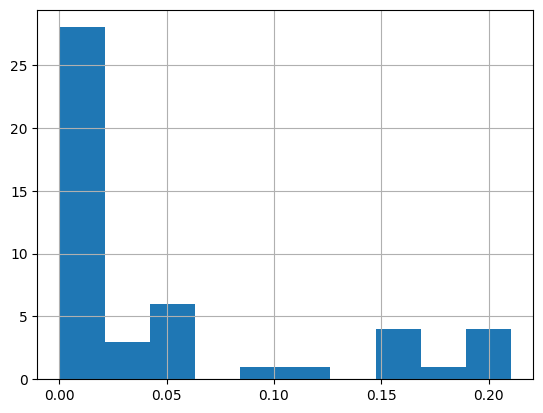

In [10]:
df_1['distance'].hist()

What is the distance of the farthest match in this set? 

Answer: np.float64(0.2102170871093757)

What is the effect? (The difference between the average Y value for X = 0 values vs. the average Y value for X = 1, where the X = 0 sample has the best match for each X = 1 value). So we use the matched sample of X = 0 and the full sample of X = 1.

In [11]:
merged_df = pd.merge(
    df_1, df_0, left_on="matched_X0_idx", right_index=True, how="inner"
)
merged_df

,X_x,Y_x,Z_x,matched_X0_idx,matched_Y,matched_Z,distance,X_y,Y_y,Z_y
1,1,1.215189,0.715189,93,0.716327,0.716327,0.001138,0,0.716327,0.716327
5,1,1.145894,0.645894,56,0.653108,0.653108,0.007214,0,0.653108,0.653108
6,1,0.937587,0.437587,41,0.437032,0.437032,0.000555,0,0.437032,0.437032
7,1,1.391773,0.891773,18,0.778157,0.778157,0.113616,0,0.778157,0.778157
8,1,1.463663,0.963663,18,0.778157,0.778157,0.185506,0,0.778157,0.778157
9,1,0.883442,0.383442,29,0.414662,0.414662,0.031220,0,0.414662,0.414662
10,1,1.291725,0.791725,18,0.778157,0.778157,0.013568,0,0.778157,0.778157
13,1,1.425597,0.925597,18,0.778157,0.778157,0.147440,0,0.778157,0.778157
17,1,1.332620,0.832620,18,0.778157,0.778157,0.054463,0,0.778157,0.778157
19,1,1.370012,0.870012,18,0.778157,0.778157,0.091855,0,0.778157,0.778157


In [12]:
merged_df['Y_x'].mean() - merged_df['Y_y'].mean()

np.float64(0.5433600652185839)

Answer: np.float64(0.5433600652185839)

How many duplicates do you end up with? (Count all but the first duplicate in each group. One way to do this is to use radius_neighbors.)

In [13]:
import numpy as np

In [16]:
# Reset df1 since it had some extra columns from previous matching
df_1_new = df[df['X'] == 1].copy()

nn = NearestNeighbors(radius=0.2)
nn.fit(df_0[['Z']])
distances, indices = nn.radius_neighbors(df_1_new[['Z']]) # For all N matches within .2 radius for each X=1

# Take each N list provided by the model for all X=1 and create 1 big list (for duplicates)
all_matched_pool_indices = np.concatenate(indices)

# Same mapping strategy as before to get original df indexes
all_matched_original_indices = df_0.index[all_matched_pool_indices]

# Count the total duplicates (excluding the first occurrence of each ID)
total_matches = len(all_matched_original_indices)
unique_matches = len(np.unique(all_matched_original_indices))
duplicate_count = total_matches - unique_matches

total_matches, duplicate_count # (737 -> total, 685 -> dups)

(737, 685)

Answer: 685

What is the effect? (Note: to compute the effect, you should take the mean of the Y values in each neighbor group, then average the Y for each group.)

In [21]:
# take the mean of the Y values in each neighbor group
y_0_values = df_0['Y'].values
group_y0_means = []
valid_x1_y_values = []

# Loop through each X=1 row and its corresponding matched X=0 indices
for idx, match_indices in enumerate(indices):
    if len(match_indices) > 0:
        # take the mean of the Y values in each neighbor group
        neighbor_y_mean = y_0_values[match_indices].mean()
        group_y0_means.append(neighbor_y_mean)
        
        # Keep the matching X=1 Y value for calculating effect
        valid_x1_y_values.append(df_1_new['Y'].iloc[idx])

# average the y for each group
overall_mean_Y_X1 = np.mean(valid_x1_y_values)
overall_mean_Y_matched_X0 = np.mean(group_y0_means)
effect = overall_mean_Y_X1 - overall_mean_Y_matched_X0
effect

np.float64(0.5688516534127853)